# Exploratory Data Analysis - MovieLens 100k

We will be exploring the basic aspects of the dataset such as :

- Number of users
- Number of movies
- Number of ratings
- Rating distribution
- Most rated movies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

In [2]:
dataPath = "../data/ml-100k"

ratingsDf = pd.read_csv(f"{dataPath}/ratings.csv", encoding="utf-8")
moviesDf = pd.read_csv(f"{dataPath}/movies.csv", encoding="utf-8")

ratingsDf.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


### Number of Users, Movies, and Ratings

In [3]:
numUsers = ratingsDf["userId"].nunique()
numMovies = ratingsDf["movieId"].nunique()
numRatings = len(ratingsDf)

print(f"Users     :   {numUsers}")
print(f"Movies    :   {numMovies}")
print(f"Ratings   :   {numRatings}")

Users     :   610
Movies    :   9724
Ratings   :   100836


### Rating Distribution

Plotting the rating distribution (0.5 - 5.0)

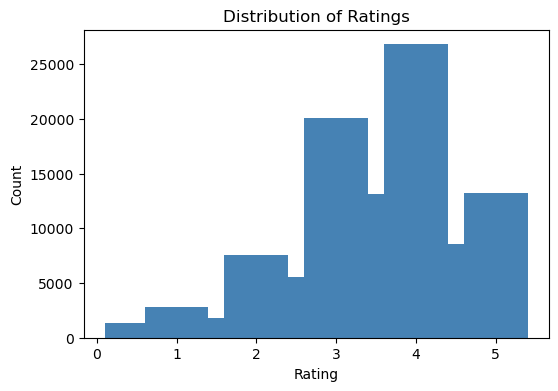

In [8]:
ratingCounts = ratingsDf["rating"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(ratingCounts.index, ratingCounts.values, color="steelblue")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

In [9]:
ratingCounts

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

### Most Rated Movies

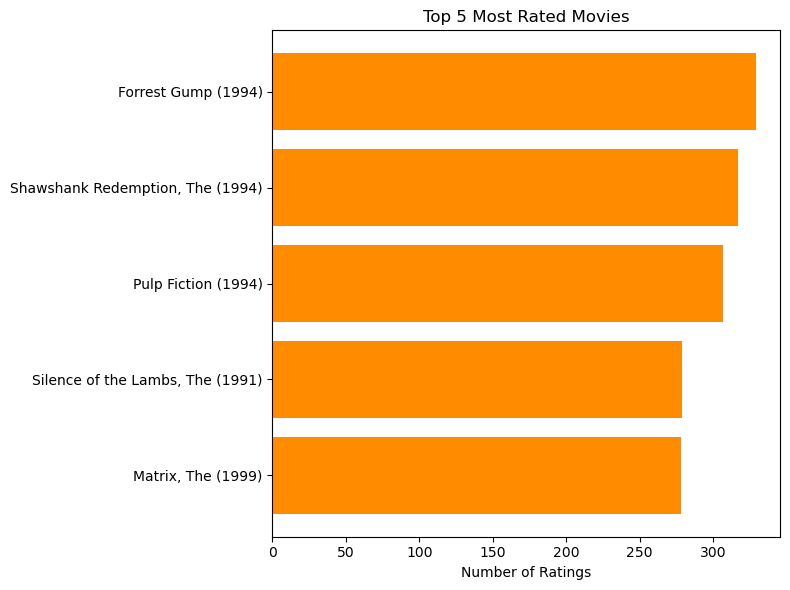

In [12]:
topN = 5

movieRatingCounts = (
    ratingsDf.groupby("movieId")
    .size()
    .reset_index(name="numRatings")
    .merge(moviesDf[["movieId", "title"]], on="movieId")
    .sort_values("numRatings", ascending=False)
    .head(topN)
)

plt.figure(figsize=(8, 6))
plt.barh(
    movieRatingCounts["title"][::-1],
    movieRatingCounts["numRatings"][::-1],
    color="darkorange"
)
plt.xlabel("Number of Ratings")
plt.title(f"Top {topN} Most Rated Movies")
plt.tight_layout()
plt.show()

In [13]:
movieRatingCounts.reset_index(drop=True)

,movieId,numRatings,title
0,356,329,Forrest Gump (1994)
1,318,317,"Shawshank Redemption, The (1994)"
2,296,307,Pulp Fiction (1994)
3,593,279,"Silence of the Lambs, The (1991)"
4,2571,278,"Matrix, The (1999)"
